In [ ]:
# considerto remove
import torch
from train import run_baseline_experiment, run_lora_experiment
from utils import plot_results
#print("CUDA available?", torch.cuda.is_available())

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import markers as mmarkers
from matplotlib import colors as mcolors

# Helper function to generate job name
def generate_job_name(merge_freq, prob, init_train_zero, gaussian_resample, deterministic_init, use_stochastic, combo):
    return "_".join([
        f"mf-{merge_freq}",
        f"p-{repr(round(prob, 8)).replace('.', ',')}",
        f"itZ-{int(init_train_zero)}",
        f"gR-{int(gaussian_resample)}",
        f"det-{int(deterministic_init)}",
        f"stoch-{int(use_stochastic)}",
        f"trainA-{int(combo['train_A'])}",
        f"trainB-{int(combo['train_B'])}",
        f"initA-{combo['init_method_A']}",
        f"initB-{combo['init_method_B']}"
    ])

In [ ]:
pwd

## Processing

### Baselines

Code script below outputs the median reached accuracy for baselines

In [ ]:
# LoRA (A:Gaussian; B:Zero) and LoRA (A:Zero; B:Gaussian)
# merge_freq_list, prob_list = [0], [0.5]
# init_train_zero_list,gaussian_resample_list = [True], [True]
# deterministic_init, use_stochastic = True, False
# param_combos = [dict(train_A=True, train_B=True, init_method_A="zero", init_method_B="gaussian"),
#                 dict(train_A=True, train_B=True, init_method_A="gaussian", init_method_B="zero")]
#----------------------------------------------
# CoLA (A:Gaussian; B:Zero) and CoLA (A:Zero; B:Gaussian)
# merge_freq_list, prob_list = [1], [0.5]
# init_train_zero_list,gaussian_resample_list = [True], [True]
# deterministic_init, use_stochastic = True, False
# param_combos = [dict(train_A=True, train_B=True, init_method_A="zero", init_method_B="gaussian"),
#                 dict(train_A=True, train_B=True, init_method_A="gaussian", init_method_B="zero")]
#----------------------------------------------
# AsymmLoRA (A:Gaussian; B:Zero) and AsymmLoRA (A:Zero; B:Gaussian)
# merge_freq_list, prob_list = [0], [0.5]
# init_train_zero_list,gaussian_resample_list = [True], [True]
# deterministic_init, use_stochastic = True, False
# param_combos = [dict(train_A=True, train_B=False, init_method_A="zero", init_method_B="gaussian"),
#                 dict(train_A=False, train_B=True, init_method_A="gaussian", init_method_B="zero")]
#----------------------------------------------
# RAC-LoRA (A:Gaussian; B:Zero) and RAC-LoRA (A:Zero; B:Gaussian)
merge_freq_list, prob_list = [1], [0.5]
init_train_zero_list, gaussian_resample_list = [True], [True]
deterministic_init, use_stochastic = True, False
param_combos = [dict(train_A=True, train_B=False, init_method_A="zero", init_method_B="gaussian"),
                dict(train_A=False, train_B=True, init_method_A="gaussian", init_method_B="zero")]


# Define output directory
output_dir = "slurm_outs"

# Iterate over the configurations and load data
for merge_freq in merge_freq_list:
    for prob in prob_list:
        for init_train_zero in init_train_zero_list:
            for gaussian_resample in gaussian_resample_list:
                for combo in param_combos:
                    job_name = generate_job_name(
                        merge_freq, prob, init_train_zero, gaussian_resample,
                        deterministic_init, use_stochastic, combo
                    )
                    
                    # Load the precomputed data
                    median_file = os.path.join(output_dir, f"median-acc_{job_name}.npy")
                    std_file = os.path.join(output_dir, f"std-acc_{job_name}.npy")
                    
                    if os.path.exists(median_file) and os.path.exists(std_file):
                        median_acc = np.load(median_file) * 100  # Convert to percentage
                        std_acc = np.load(std_file) * 100       # Convert to percentage
                        
                        # Format the output
                        formatted_result = f"{median_acc:.2f} ± {std_acc:.1f}"
                        print(f"Results for job: {job_name}")
                        print(f"Median ± Std: {formatted_result}\n")
                    else:
                        print(f"No data found for job: {job_name}")


In [2]:
# 4o; version 3

def plot_bernoulli_lora_settings(settings):
    # Parameters
    merge_freq_list = [1]
    prob_list = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
    output_dir = "slurm_outs"
    show_plot = 1  # Flag to control whether to show the plot

    # Initialize colors and markers
    def init_colors_and_markers():
        color_ar = ['red', 'orange', 'aqua', 'violet', 'cornflowerblue', 'coral', 'lime', 'goldenrod', 'maroon',
                    'black', 'brown', 'yellowgreen', "purple", "violet", "magenta", "green", "chocolate", "crimson", 'blue', 'darkgreen', 'darkorange']
        all_colors = mcolors.CSS4_COLORS
        remaining_colors = list(set(all_colors.keys()) - set(color_ar))
        color_ar.extend(remaining_colors)
        marker_ar = ["*", "v", ">", "s", "p", "P", "h", "H", "+", "x", "X", "D", "d", "|", "_", 1, 2, 3, 4, 5, 6, 7, 8, 9, "^", "<", "o"]
        all_markers = list(mmarkers.MarkerStyle.markers.keys())
        remaining_markers = list(set(all_markers) - set(marker_ar))
        marker_ar.extend(remaining_markers)
        return color_ar, marker_ar

    color_ar, marker_ar = init_colors_and_markers()

    # Update matplotlib styles
    if show_plot:
        plt.rcParams.update({
            'lines.linewidth': 2,
            'xtick.labelsize': 25,
            'ytick.labelsize': 25,
            'legend.fontsize': 25,
            'axes.titlesize': 25,
            'axes.labelsize': 25,
            'figure.figsize': [10, 8],
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
            'text.usetex': True,
            'font.family': 'serif',
        })

    # Plotting (if enabled)
    if show_plot:
        fig, ax = plt.subplots()

    highest_median_acc = -np.inf
    best_params = None

    for idx, setting in enumerate(settings):
        median_accs = []
        std_accs = []

        for prob in prob_list:
            job_name = generate_job_name(
                merge_freq=1, prob=prob,
                init_train_zero=setting['init_train_zero'],
                gaussian_resample=setting['gaussian_resample'],
                deterministic_init=setting['deterministic_init'],
                use_stochastic=setting['use_stochastic'],
                combo=setting
            )

            # Load the precomputed data
            median_file = os.path.join(output_dir, f"median-acc_{job_name}.npy")
            std_file = os.path.join(output_dir, f"std-acc_{job_name}.npy")

            if os.path.exists(median_file) and os.path.exists(std_file):
                median_acc = np.load(median_file) * 100  # Convert to percentage
                std_acc = np.load(std_file) * 100       # Convert to percentage

                median_accs.append(median_acc)
                std_accs.append(std_acc)

                # Check for highest median accuracy
                if median_acc > highest_median_acc:
                    highest_median_acc = median_acc
                    best_params = {
                        'median_acc': median_acc,
                        'std_acc': std_acc,
                        'merge_freq': 1,
                        'prob': prob,
                        **setting
                    }
            else:
                print(f"Data not found for job: {job_name}")
                median_accs.append(None)
                std_accs.append(None)

        # Convert lists to arrays and filter None values
        median_accs = np.array(median_accs, dtype=np.float32)
        std_accs = np.array(std_accs, dtype=np.float32)

        # Plot (if enabled)
        if show_plot:
            valid_idxs = ~np.isnan(median_accs)
            x_vals = np.array(prob_list)[valid_idxs]
            x_vals = 1 - x_vals  # Convertatation due to the inconsistency between pseudocode in the paper and the code in the callback_stochastic.py
            y_vals = median_accs[valid_idxs]
            y_std = std_accs[valid_idxs]

            ax.plot(
                x_vals,
                y_vals,
                label=f"Setting {idx + 1}",
                color=color_ar[idx % len(color_ar)],
                marker=marker_ar[idx % len(marker_ar)],
                markevery=list(range(0, len(prob_list), 2)),
                markersize=15,
                markerfacecolor=color_ar[idx % len(color_ar)],
                markeredgecolor='black',
                linestyle="solid"
            )

            # Add std as fill_between
            upper_bound = y_vals + y_std
            lower_bound = y_vals - y_std
            lower_bound = np.maximum(lower_bound, 1e-10)  # Ensure non-negative values
            ax.fill_between(
                x_vals, lower_bound, upper_bound,
                color=color_ar[idx % len(color_ar)], alpha=0.2
            )

    # Customize the plot (if enabled)
    if show_plot:
        ax.set_xlabel(r"$p$")
        ax.set_ylabel("Accuracy on test")
        #ax.set_title("RC-LoRA: Median Accuracy")
        ax.grid(True)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

        # Show or save the plot
        plt.tight_layout()
        plt.show()

    # Output the highest median accuracy and corresponding parameters
    if best_params:
        print("Highest Median Accuracy:")
        print(f"{best_params['median_acc']:.2f} ± {best_params['std_acc']:.2f}")
        print("Corresponding Parameters:")
        for key, value in best_params.items():
            if key not in ['median_acc', 'std_acc']:
                print(f"{key}: {value}")



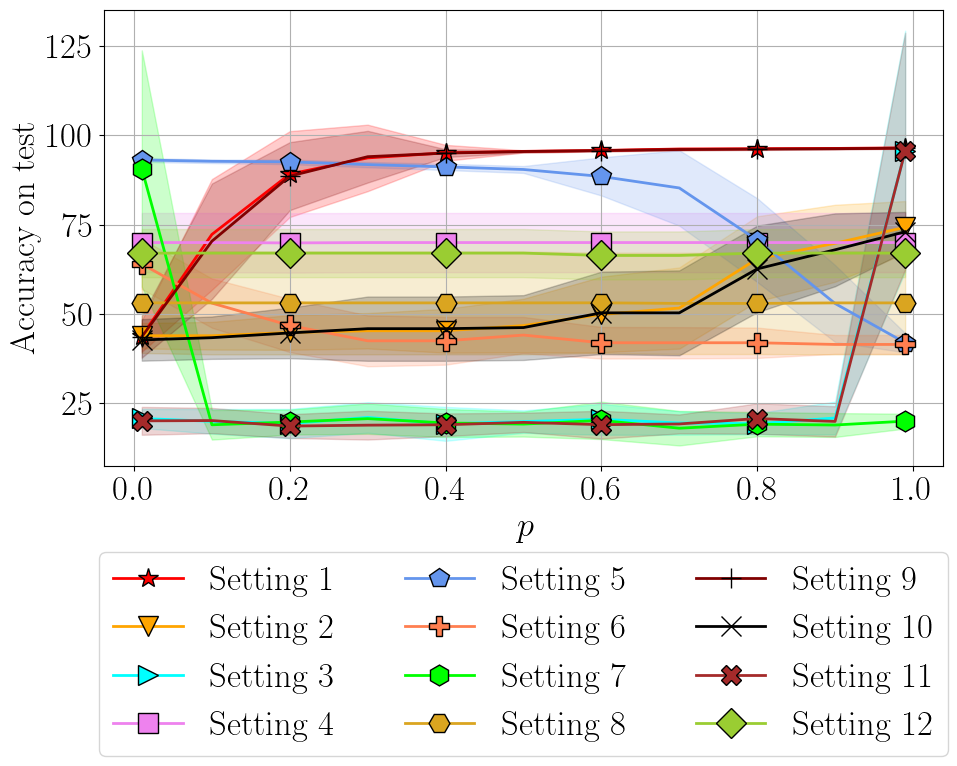

Highest Median Accuracy:
96.46 ± 0.17
Corresponding Parameters:
merge_freq: 1
prob: 0.01
train_A: True
train_B: False
init_method_A: zero
init_method_B: gaussian
init_train_zero: True
gaussian_resample: True
deterministic_init: True
use_stochastic: True


In [3]:
# Define all the RC-LoRA settings
rc_lora_settings = [
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': True, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': False, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': False, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': False, 'use_stochastic':True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': False, 'use_stochastic':True}
]

plot_bernoulli_lora_settings(rc_lora_settings)



In [4]:
p = 0.99
p*912+(1-p)*133 

904.21

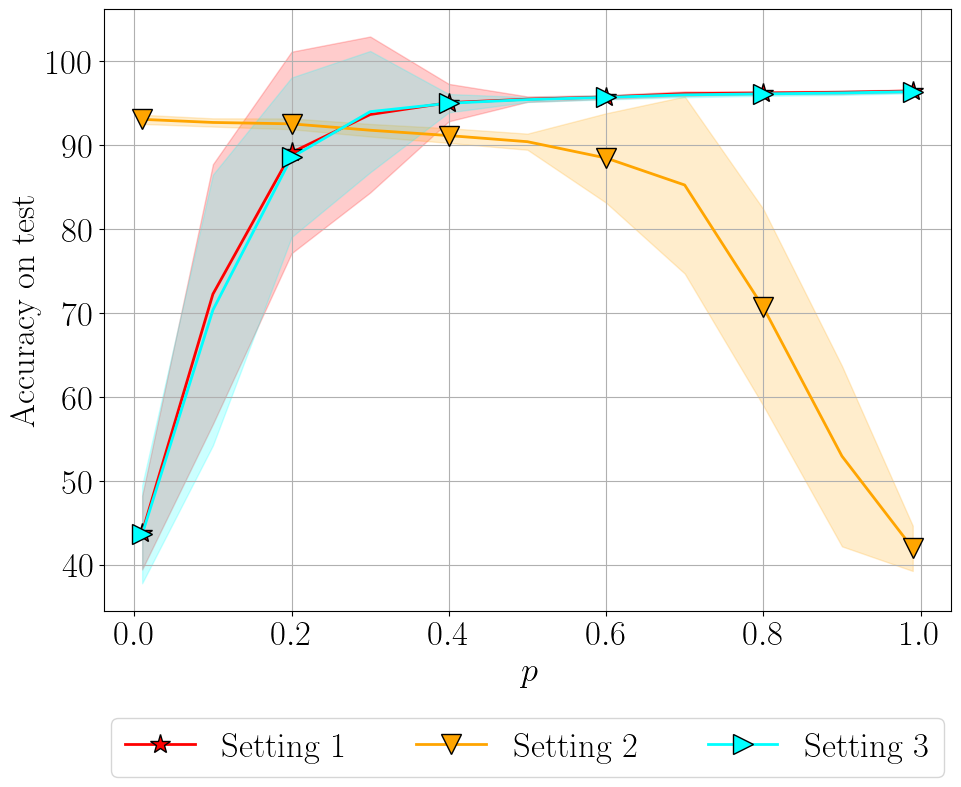

Highest Median Accuracy:
96.46 ± 0.17
Corresponding Parameters:
merge_freq: 1
prob: 0.01
train_A: True
train_B: False
init_method_A: zero
init_method_B: gaussian
init_train_zero: True
gaussian_resample: True
deterministic_init: True
use_stochastic: True


In [7]:
# best settings

# Define all the RC-LoRA settings
rc_lora_settings = [
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': True},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': True},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic':True},
    #{'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': True},
    #{'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': True},
    #{'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': False, 'use_stochastic':True},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': False, 'deterministic_init': False},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': True, 'deterministic_init': False},
    #{'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': False, 'gaussian_resample': False, 'deterministic_init': False}
]

plot_bernoulli_lora_settings(rc_lora_settings)



In [8]:
# 4o; version 5; RC-LoRA and RAC-LoRA settings
# Plotting function
def plot_bernoulli_lora_settings(rc_settings, rac_settings):
    # Parameters
    merge_freq_list = [1]
    prob_list = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
    output_dir = "slurm_outs"
    show_plot = 1  # Flag to control whether to show the plot

    # Initialize colors and markers
    def init_colors_and_markers():
        color_ar = ['red', 'orange', 'aqua', 'violet', 'cornflowerblue', 'coral', 'lime', 'goldenrod', 'maroon',
                    'black', 'brown', 'yellowgreen', "purple", "magenta", "green", "chocolate", "crimson", 'blue']
        all_colors = mcolors.CSS4_COLORS
        remaining_colors = list(set(all_colors.keys()) - set(color_ar))
        color_ar.extend(remaining_colors)
        marker_ar = ["*", "v", ">", "s", "p", "P", "h", "H", "+", "x", "X", "D", "d", "|", "_", 1, 2, 3, 4, 5, 6, 7, 8, 9, "^", "<", "o"]
        all_markers = list(mmarkers.MarkerStyle.markers.keys())
        remaining_markers = list(set(all_markers) - set(marker_ar))
        marker_ar.extend(remaining_markers)
        return color_ar, marker_ar

    color_ar, marker_ar = init_colors_and_markers()

    # Update matplotlib styles
    if show_plot:
        plt.rcParams.update({
            'lines.linewidth': 2,
            'xtick.labelsize': 25,
            'ytick.labelsize': 25,
            'legend.fontsize': 25,
            'axes.titlesize': 25,
            'axes.labelsize': 25,
            'figure.figsize': [10, 8],
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
            'text.usetex': True,
            'font.family': 'serif',
        })

    # Plotting (if enabled)
    if show_plot:
        fig, ax = plt.subplots()

    highest_median_acc = -np.inf
    best_params = None

    # Plot RC-LoRA settings
    for idx, setting in enumerate(rc_settings):
        median_accs = []
        std_accs = []

        for prob in prob_list:
            job_name = generate_job_name(
                merge_freq=1, prob=prob,
                init_train_zero=setting['init_train_zero'],
                gaussian_resample=setting['gaussian_resample'],
                deterministic_init=setting['deterministic_init'],
                use_stochastic=setting['use_stochastic'],
                combo=setting
            )

            # Load the precomputed data
            median_file = os.path.join(output_dir, f"median-acc_{job_name}.npy")
            std_file = os.path.join(output_dir, f"std-acc_{job_name}.npy")

            if os.path.exists(median_file) and os.path.exists(std_file):
                median_acc = np.load(median_file) * 100  # Convert to percentage
                std_acc = np.load(std_file) * 100       # Convert to percentage

                median_accs.append(median_acc)
                std_accs.append(std_acc)

                # Check for highest median accuracy
                if median_acc > highest_median_acc:
                    highest_median_acc = median_acc
                    best_params = {
                        'median_acc': median_acc,
                        'std_acc': std_acc,
                        'merge_freq': 1,
                        'prob': prob,
                        **setting
                    }
            else:
                print(f"Data not found for job: {job_name}")
                median_accs.append(None)
                std_accs.append(None)

        # Convert lists to arrays and filter None values
        median_accs = np.array(median_accs, dtype=np.float32)
        std_accs = np.array(std_accs, dtype=np.float32)

        # Plot RC-LoRA (if enabled)
        if show_plot:
            valid_idxs = ~np.isnan(median_accs)
            x_vals = np.array(prob_list)[valid_idxs]
            x_vals = 1 - x_vals  # Convertatation due to the inconsistency between pseudocode in the paper and the code in the callback_stochastic.py
            y_vals = median_accs[valid_idxs]
            y_std = std_accs[valid_idxs]

            ax.plot(
                x_vals,
                y_vals,
                label=f"RC-LoRA Setting {idx + 1}",
                color=color_ar[idx % len(color_ar)],
                marker=marker_ar[idx % len(marker_ar)],
                markevery=list(range(0, len(prob_list), 2)),
                markersize=15,
                markerfacecolor=color_ar[idx % len(color_ar)],
                markeredgecolor='black',
                linestyle="solid"
            )

            # Add std as fill_between
            upper_bound = y_vals + y_std
            lower_bound = y_vals - y_std
            lower_bound = np.maximum(lower_bound, 1e-10)  # Ensure non-negative values
            ax.fill_between(
                x_vals, lower_bound, upper_bound,
                color=color_ar[idx % len(color_ar)], alpha=0.2
            )

    # Plot RAC-LoRA settings as constant lines
    for idx, setting in enumerate(rac_settings):
        job_name = generate_job_name(
            merge_freq=1, prob=0.5,  # Fixed probability
            init_train_zero=setting['init_train_zero'],
            gaussian_resample=setting['gaussian_resample'],
            deterministic_init=setting['deterministic_init'],
            use_stochastic=setting['use_stochastic'],
            combo=setting
        )

        # Load the precomputed data
        median_file = os.path.join(output_dir, f"median-acc_{job_name}.npy")
        std_file = os.path.join(output_dir, f"std-acc_{job_name}.npy")

        if os.path.exists(median_file) and os.path.exists(std_file):
            median_acc = np.load(median_file) * 100  # Convert to percentage
            std_acc = np.load(std_file) * 100       # Convert to percentage

            # Plot constant line
            # ax.axhline(
            #     y=median_acc, 
            #     color=color_ar[len(rc_settings) + idx % len(color_ar)],
            #     xmin=0.01,
            #     xmax=0.99,
            #     linestyle="dashed", label=f"RAC-LoRA Setting {idx + 1}"
            # )
            
            ax.plot(
            [0.0, 1.0],  # Limits p from min to max
            [median_acc, median_acc],  # Constant y-value
            linestyle="dashed",
            color=color_ar[len(rc_settings) + idx % len(color_ar)],
            label=f"RAC-LoRA Setting {idx + 1}"
        )
            
            
            # Add std as fill_between
            upper_bound = median_acc + std_acc
            lower_bound = median_acc - std_acc
            lower_bound = np.maximum(lower_bound, 1e-10)  # Ensure non-negative values
            ax.fill_between(
                [0.0, 1.0], 
                lower_bound, upper_bound,
                color=color_ar[len(rc_settings) + idx % len(color_ar)],
                alpha=0.2
            )

    # Customize the plot (if enabled)
    if show_plot:
        ax.set_xlabel(r"$p$")
        ax.set_ylabel("Accuracy on test")
        ax.grid(True)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

        # Show or save the plot
        plt.tight_layout()
        plt.show()

    # Output the highest median accuracy and corresponding parameters
    if best_params:
        print("Highest Median Accuracy:")
        print(f"{best_params['median_acc']:.2f} ± {best_params['std_acc']:.2f}")
        print("Corresponding Parameters:")
        for key, value in best_params.items():
            if key not in ['median_acc', 'std_acc']:
                print(f"{key}: {value}")



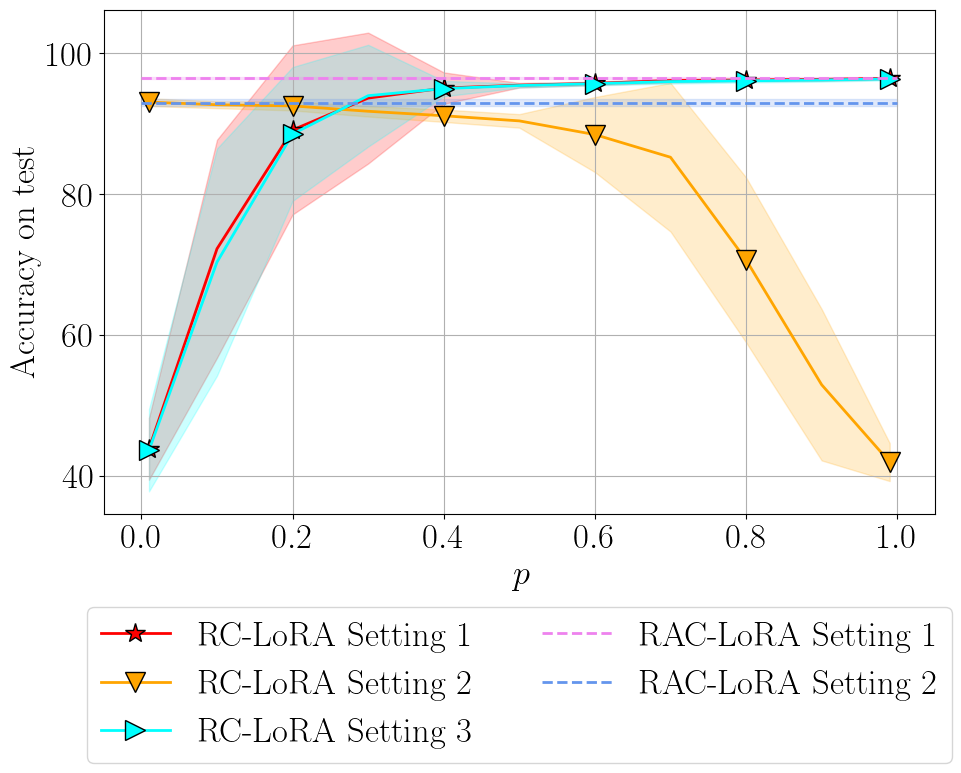

Highest Median Accuracy:
96.46 ± 0.17
Corresponding Parameters:
merge_freq: 1
prob: 0.01
train_A: True
train_B: False
init_method_A: zero
init_method_B: gaussian
init_train_zero: True
gaussian_resample: True
deterministic_init: True
use_stochastic: True


In [9]:
# Define all the RC-LoRA settings
rc_lora_settings = [
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic': True},
    {'train_A': False, 'train_B': True, 'init_method_A': 'gaussian', 'init_method_B': 'zero', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic': True},
    {'train_A': True, 'train_B': False, 'init_method_A': 'zero', 'init_method_B': 'gaussian', 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': False, 'use_stochastic': True}
]

# Define all the RAC-LoRA settings
rac_lora_settings = [
    {'train_A': True, 'train_B': False, 'init_method_A': "zero", 'init_method_B': "gaussian", 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic': False},
    {'train_A': False, 'train_B': True, 'init_method_A': "gaussian", 'init_method_B': "zero", 'init_train_zero': True, 'gaussian_resample': True, 'deterministic_init': True, 'use_stochastic': False}
]

# Plot both RC-LoRA and RAC-LoRA settings
plot_bernoulli_lora_settings(rc_lora_settings, rac_lora_settings)


# Archived cells 